# 1 - Problema - Curse of Dimensionality

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances


In [2]:
samples = n = 100
dims = [2, 5, 10, 50, 100, 200, 1000, 10000]
avg_distances = []

- `dims` è una lista di dimensionalità che vogliamo testare
- `avg_distances` è una lista vuota che conterrà le distanze medie per ogni dimensionalità

In [3]:
for dim in dims:
    # Generaro n punti casuali in uno spazio dim-dimensionale
    X = np.random.random((n, dim))
    # Calcolare tutte le distanze a coppie
    distances = euclidean_distances(X)
    # Calcolare la distanza media (escludendo la diagonale che è 0)
    avg_distance = np.sum(distances) / (n * (n-1))
    avg_distances.append(avg_distance)

Qui creiamo un array numpy di forma (100, dim) riempito con valori casuali tra 0 e 1:

- 100 è il numero di punti che stiamo generando
- `dim` è la dimensionalità dello spazio (cambia ad ogni iterazione)
- Ogni punto è quindi un vettore con `dim` componenti casuali tra 0 e 1


```python
    # Calcolare tutte le distanze a coppie
    distances = euclidean_distances(X)
```
Questa funzione calcola la distanza euclidea tra ogni possibile coppia di punti in X:

- Produce una matrice simmetrica 100×100
- Il valore alla posizione [i,j] è la distanza tra il punto i e il punto j
- La diagonale contiene zeri (distanza di un punto da se stesso)
```python
    # Calcolare la distanza media (escludendo la diagonale che è 0)
    avg_distance = np.sum(distances) / (100 * 99)
    avg_distances.append(avg_distance)
```
Qui:

- Sommiamo tutte le distanze nella matrice
- Dividiamo per il numero di coppie distinte: con 100 punti abbiamo 100×99/2 coppie (dividiamo per 2 perché la matrice è simmetrica), ma poiché sommiamo l'intera matrice (quindi contiamo ogni coppia due volte) dividiamo per 100×99
- Aggiungiamo questa distanza media alla nostra lista


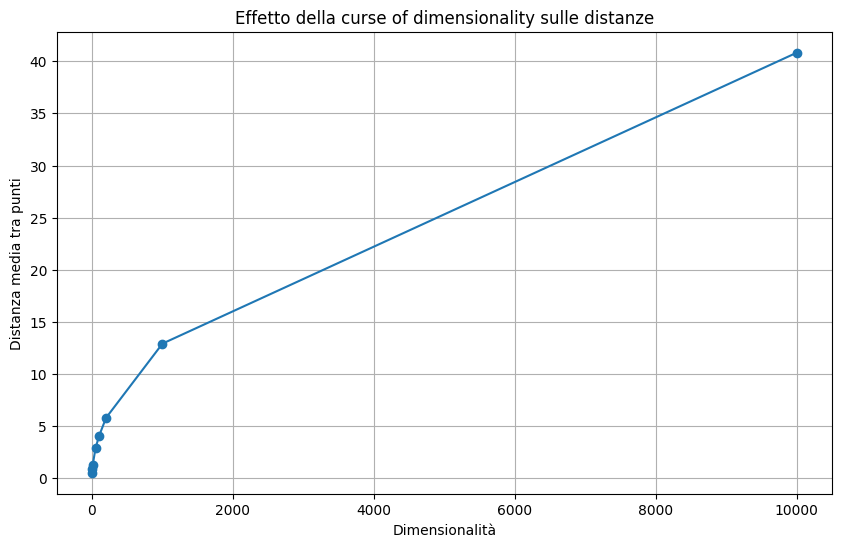

In [4]:
plt.figure(figsize=(10, 6))
plt.plot(dims, avg_distances, 'o-')
plt.xlabel('Dimensionalità')
plt.ylabel('Distanza media tra punti')
plt.title('Effetto della curse of dimensionality sulle distanze')
plt.grid(True)
plt.show()

## Cosa dimostra questo?

Questo dimostra un aspetto fondamentale della curse of dimensionality:

1. All'aumentare delle dimensioni, la distanza media tra punti casuali aumenta
    
2. Questo significa che in spazi ad alta dimensionalità, i punti tendono ad essere molto distanti tra loro, rendendo i dati estremamente sparsi
    
3. Questa sparsità ha importanti implicazioni per il machine learning:
    
    - Gli algoritmi basati sulla vicinanza (come k-NN) diventano meno efficaci
    - Diventa più difficile trovare pattern nei dati
    - Le previsioni richiedono estrapolazioni su distanze maggiori
    - Si richiede una quantità esponenzialmente maggiore di dati per mantenere la stessa densità

## 2 Teoria della proiezione

## 2.1 Proiezione Lineare

### Il problema della alta dimensionalità

In molti problemi reali, abbiamo dati con numerose dimensioni (features). Tuttavia, spesso molte di queste dimensioni:

- Contengono informazioni ridondanti
- Hanno poca varianza (sono quasi costanti)
- Sono altamente correlate tra loro

### Definizione matematica della proiezione

La proiezione è il processo di mappare punti da uno spazio di dimensione superiore a uno spazio di dimensione inferiore. Matematicamente:

Se abbiamo dati in uno spazio originale $ℝ^n$ (n-dimensionale) vogliamo trovare una rappresentazione in $ℝ^d$ dove d < n.

Per uno spazio di proiezione definito da una base ortonormale {$v_1$, $v_2$, ..., $v_d$}, la proiezione di un punto $x$ ∈ $ℝ^n$ è:

```
x' = [<x,v₁>, <x,v₂>, ..., <x,vd>]
```

dove <x,vᵢ> rappresenta il prodotto scalare di x con il vettore vᵢ.

### Geometricamente, stiamo:

- Identificando un sottospazio (come un piano in 3D)
- Proiettando ogni punto perpendicolarmente su questo sottospazio
- Usando le coordinate nel sottospazio come nuova rappresentazione

###  Scelta del sottospazio

La scelta cruciale è: quale sottospazio scegliere per la proiezione?

Il criterio ottimale è scegliere il sottospazio che:

- Massimizza la varianza dei dati proiettati, o
- Minimizza l'errore di ricostruzione (distanza tra punti originali e loro proiezioni)

**SPOILER** - PCA risolve esattamente questo problema trovando gli assi ortogonali che massimizzano la varianza.

# 3. Principal Component Analysis (PCA): Teoria e Implementazione

## Teoria di PCA: Approccio Step by Step

### Step 1: Il problema fondamentale

PCA (Principal Component Analysis) è l'algoritmo di riduzione della dimensionalità più popolare e ampiamente utilizzato. 

Affronta il problema di trovare una rappresentazione a bassa dimensionalità che preservi al massimo l'informazione contenuta nei dati originali.

### Step 1: Definizione matematica di manifold

Un manifold d-dimensionale in uno spazio n-dimensionale (con $d$ < $n$) è un insieme di punti che localmente assomiglia a uno spazio euclideo $ℝ^d$.

Formalmente: per ogni punto $p$ sul manifold, esiste un intorno $U$ di $p$ e ud un mapping continuo e invertibile $\phi: U → ℝ^d$.

### Step 2: L'intuizione geometrica

PCA si basa su un'idea geometrica fondamentale:

- I dati ad alta dimensionalità spesso risiedono vicino a un sottospazio di dimensionalità molto inferiore - **manifold hypothesis**
- Questo sottospazio può essere approssimato da un iperpiano
- Vogliamo trovare l'iperpiano che giace più vicino ai nostri dati


### Step 3: Criterio di ottimalità

PCA identifica l'asse che rappresenta la maggior quantità di varianza nel training set. Inoltre, trova un secondo asse, ortogonale al primo, che rappresenta la maggior quantità di varianza residua. In uno spazio di dimensione superiore, PCA continuerebbe a trovare assi aggiuntivi, tutti ortogonali tra loro.

Il criterio di ottimalità di PCA può essere formulato in due modi equivalenti:

1. **Massimizzazione della varianza**: Trovare gli assi lungo i quali i dati mostrano la maggiore variabilità dei dati
2. **Minimizzazione dell'errore di ricostruzione**: Trovare il sottospazio che minimizza la distanza media tra i punti originali e le loro proiezioni

### Step 4: Componenti Principali

L'i-esimo asse trovato da PCA è chiamato i-esima Componente Principale (PC) dei dati. La prima PC è l'asse su cui giace il vettore c₁, la seconda PC è l'asse su cui giace il vettore c₂, e così via.

Queste componenti principali hanno proprietà importanti:

- Sono ortogonali tra loro (formano una base ortonormale)
- Sono ordinate per importanza (quantità di varianza spiegata)
- Sono combinazioni lineari delle feature originali


### Step 5: Lo strumento matematico SVD

Come si trovano le componenti principali? PCA viene comunemente calcolato utilizzando la Decomposizione in Valori Singolari (SVD) della matrice dei dati centrata.

L'algoritmo SVD decompone la matrice dei dati X in tre matrici fondamentali:

```
X = U · Σ · V^T
```

dove:

- U = matrice ortonormale (spazio delle righe)
- Σ = matrice diagonale di valori singolari (scalari non negativi)
- V^T = trasposta di V, direzioni ortonormali nello spazio delle colonne

La matrice V contiene i vettori unitari che definiscono tutte le componenti principali che stiamo cercando.

### Step 6: Procedura completa dell'algoritmo PCA

1. **Centrare i dati**: 
   Il primo passo fondamentale è centrare i dati rimuovendo la media di ciascuna feature. Dato un dataset $X$ di dimensioni $n \times m$ (n campioni, m feature), calcoliamo:
   $$X_{cent} = X - \bar{X}$$
   dove $\bar{X}$ è il vettore delle medie delle colonne, replicato per ogni riga. In pratica: $\bar{X}_j = \frac{1}{n}\sum_{i=1}^{n} X_{ij}$ per ogni feature j.
   
   Questo passaggio è cruciale perché PCA cerca direzioni di massima varianza, e la varianza è definita rispetto alla media!
    
2. **Calcolare SVD**: 
   Applichiamo la decomposizione SVD alla matrice dei dati centrati:
   $$X_{cent} = U \cdot \Sigma \cdot V^T$$
   Questo ci fornisce:
   - $U$: matrice $n \times n$ dei vettori singolari sinistri
   - $\Sigma$: matrice diagonale $n \times m$ dei valori singolari
   - $V$: matrice $m \times m$ dei vettori singolari destri (le cui colonne sono le componenti principali)
    
3. **Scegliere il numero di componenti**: 
   Decidiamo quante componenti principali $d$ mantenere (con $d < m$). Possiamo basarci su:
   - Varianza spiegata cumulativa desiderata (es. 95%)
   - Numero fisso di componenti
   - Scree plot dei valori singolari
   
   I valori singolari in $\Sigma$ ci indicano l'importanza di ogni componente: la varianza spiegata dalla i-esima componente è proporzionale a $\sigma_i^2$.
    
4. **Proiettare i dati**: 
   Per ottenere il dataset ridotto a $d$ dimensioni, proiettiamo i dati centrati sulle prime $d$ componenti principali:
   $$X_{pca} = X_{cent} \cdot V_d$$
   dove $V_d$ è la matrice $m \times d$ contenente le prime $d$ colonne di $V$.
   
   Alternativamente, possiamo scrivere: $X_{pca} = U_d \cdot \Sigma_d$ dove $U_d$ e $\Sigma_d$ sono le versioni troncate di $U$ e $\Sigma$.

### Facciamo un esempio

#### Creo un dataset


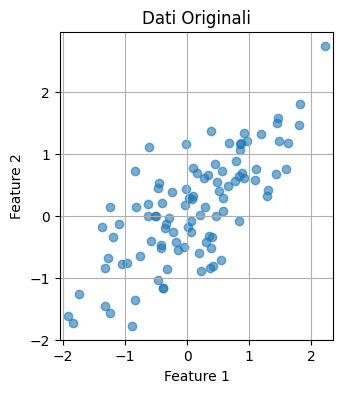

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Creiamo un dataset semplice 2D per visualizzazione
np.random.seed(42)
# Generiamo dati con correlazione
mean = [0, 0]
cov = [[1, 0.8], [0.8, 1]]  # Correlazione positiva
X = np.random.multivariate_normal(mean, cov, 100)

# Visualizziamo i dati originali
plt.figure(figsize=(12, 4))
plt.subplot(131)
plt.scatter(X[:, 0], X[:, 1], alpha=0.6)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Dati Originali')
plt.axis('equal')
plt.grid(True)

#### Step 1 - Centro i dati

In [6]:
X_centered = X - np.mean(X, axis=0)

#### Step 2 - Sfrutto SVD per decomporre il dataset in 3 matrici

In [7]:
U, S, Vt = np.linalg.svd(X_centered, full_matrices=True)

#### Analizziamo le tre matrici

In [8]:
# Ispezioniamo le dimensioni delle matrici
print("Forma della matrice originale X:", X.shape)
print("Forma di U:", U.shape) 
print ("--> U ha dimensioni (M, k), dove k = min(M, N)")
print("Forma di S (valori singolari):", S.shape)
print("Forma di V^T:", Vt.shape)
print("\nValori singolari:", S)

Forma della matrice originale X: (100, 2)
Forma di U: (100, 100)
--> U ha dimensioni (M, k), dove k = min(M, N)
Forma di S (valori singolari): (2,)
Forma di V^T: (2, 2)

Valori singolari: [11.43212295  4.44190455]


##### S restituiti come vettore diagonale invece che come matrice 100x2

In [11]:
# U
U

array([[-7.17475924e-02,  2.00812272e-02,  1.91387147e-02, ...,
        -4.03973650e-02,  8.58074863e-02,  4.23735393e-03],
       [-9.04254596e-02, -1.46485601e-01,  2.31935446e-02, ...,
        -2.68730447e-02, -3.19693629e-02,  1.20074582e-01],
       [ 1.40710153e-02,  2.64653229e-02,  9.99206702e-01, ...,
         1.26230181e-03, -1.01918419e-03, -2.32089934e-03],
       ...,
       [-3.40859853e-02, -3.40738780e-02,  1.19754484e-03, ...,
         9.97903233e-01,  2.71582824e-03,  2.50827980e-03],
       [ 9.00854742e-02, -1.54851026e-02, -6.20502819e-04, ...,
         2.16463947e-03,  9.91954730e-01,  4.31226530e-03],
       [-1.97097774e-02,  1.19264194e-01, -2.65795007e-03, ...,
         3.23405264e-03,  2.71284602e-03,  9.87043430e-01]],
      shape=(100, 100))

In [12]:
S

array([11.43212295,  4.44190455])

In [13]:
Vt

array([[ 0.71749523,  0.69656342],
       [ 0.69656342, -0.71749523]])

#### Visualizziamo le componenti principali (colonne di V)


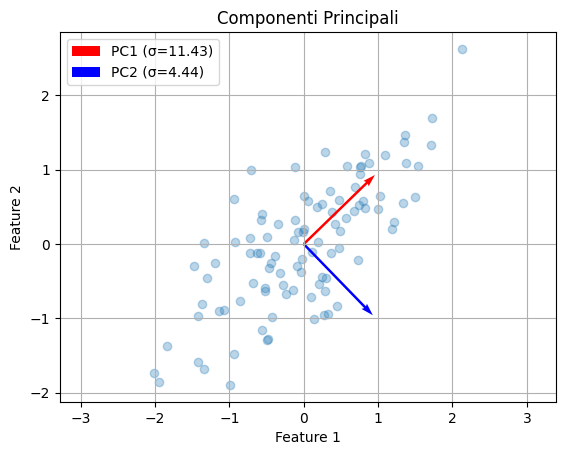

In [9]:
plt.scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.3)
origin = [0, 0]
# Prima componente principale (prima colonna di V)
plt.quiver(*origin, Vt[0, 0], Vt[0, 1], scale=5, color='red', width=0.005, 
           label=f'PC1 (σ={S[0]:.2f})')
# Seconda componente principale
plt.quiver(*origin, Vt[1, 0], Vt[1, 1], scale=5, color='blue', width=0.005,
           label=f'PC2 (σ={S[1]:.2f})')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Componenti Principali')
plt.axis('equal')
plt.legend()
plt.grid(True)

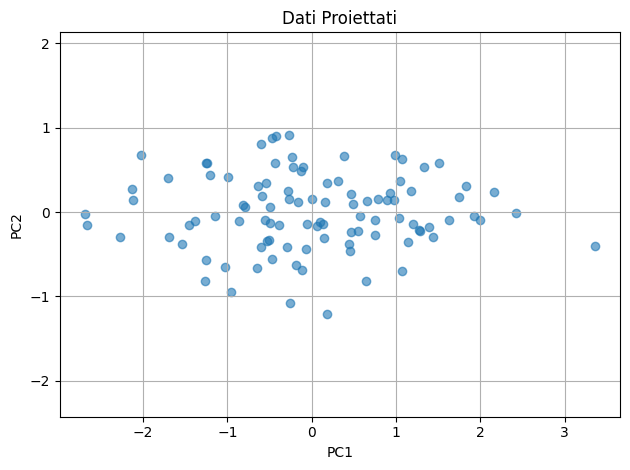

In [14]:
d = 2 #numero di dimensioni da tenere
# Proiettiamo i dati sulle componenti principali
X_pca = X_centered @ Vt[:d].T  # moltiplicazione matriciale

plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2') 
plt.title('Dati Proiettati')
plt.axis('equal')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Ispezioniamo nel dettaglio le matrici
print("\n=== Matrice V (Componenti Principali) ===")
print("Ogni riga di V^T (colonna di V) è una componente principale:")
for i in range(Vt.shape[0]):
    print(f"PC{i+1}: {Vt[i]}")

print("\n=== Interpretazione dei valori singolari ===")
variance_explained = (S**2) / np.sum(S**2) #varianza proporzionale al quadrato delle valori in sigma
for i, var in enumerate(variance_explained):
    print(f"PC{i+1} spiega il {var:.1%} della varianza totale")

# Verifichiamo che le componenti siano ortogonali
print("\n=== Verifica ortogonalità delle componenti ===")
print("Prodotto scalare PC1·PC2:", np.dot(Vt[0], Vt[1]))
print("(Dovrebbe essere ~0)")

print("\n=== Ricostruzione dei dati ===")

# Con full_matrices=True (nella decomposizione), dobbiamo costruire Σ come matrice rettangolare
m, n = X_centered.shape  # m=100, n=2 nel nostro esempio
Sigma_full = np.zeros((m, n))
Sigma_full[:min(m,n), :min(m,n)] = np.diag(S)

# Ricostruzione
X_reconstructed = (U @ Sigma_full @ Vt) + np.mean(X, axis=0)
reconstruction_error = np.mean((X - X_reconstructed)**2)
print(f"Errore quadratico medio di ricostruzione: {reconstruction_error:.2e}")


=== Matrice V (Componenti Principali) ===
Ogni riga di V^T (colonna di V) è una componente principale:
PC1: [0.71749523 0.69656342]
PC2: [ 0.69656342 -0.71749523]

=== Interpretazione dei valori singolari ===
PC1 spiega il 86.9% della varianza totale
PC2 spiega il 13.1% della varianza totale

=== Verifica ortogonalità delle componenti ===
Prodotto scalare PC1·PC2: 0.0
(Dovrebbe essere ~0)

=== Ricostruzione dei dati ===
Errore quadratico medio di ricostruzione: 1.19e-31


### Step 7: Scelta del numero di componenti

Il rapporto di varianza spiegata indica la proporzione della varianza del dataset che si trova lungo ciascuna componente principale. Invece di scegliere arbitrariamente il numero di dimensioni da ridurre, è più semplice scegliere il numero di dimensioni che sommano una porzione sufficientemente grande della varianza (ad esempio, il 95%).

### Step 8: Ricostruzione dei dati

È anche possibile decomprimere il dataset ridotto riportandolo alle sue dimensioni originali applicando la trasformazione inversa della proiezione PCA: 
$$
X̂_{cent} = X_{d-proj} · W_d^T 
$$
$$
X̂ = X̂_{cent} + X̄
$$
Questo non restituirà i dati originali, poiché la proiezione ha perso un po' di informazione (la varianza che è stata scartata!), ma sarà probabilmente vicino ai dati originali. La distanza quadratica media tra i dati originali e quelli ricostruiti (compressi e poi decompressi) è chiamata errore di ricostruzione.


### Step 9: Vantaggi e limitazioni di PCA

**Vantaggi**:

- È semplice e veloce - un metodo lineare efficiente con soluzione in forma chiusa
- Si concentra sulla varianza - cattura le direzioni di massima varianza
- Efficace per il denoising - le componenti a bassa varianza possono essere scartate
- Proiettabile - può essere facilmente applicato a nuovi dati

**Limitazioni**:

- Solo lineare - fallisce con strutture non lineari
- Sensibile alla scala - richiede standardizzazione delle feature
- Difficile da interpretare - le componenti sono combinazioni lineari
- Focus globale - approccio globale che non preserva necessariamente strutture locali

## Implementazione di PCA

L'implementazione manuale di PCA prevede i seguenti passaggi:

In [16]:
def pca_from_scratch(X, n_components):
    # 1. Centrare i dati
    X_centered = X - np.mean(X, axis=0)
    
    # 2. Calcolare SVD
    U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
    
    # 3. Estrarre le prime n_components colonne di V come matrice di proiezione
    W = Vt.T[:, :n_components]
    
    # 4. Proiettare i dati
    X_pca = X_centered.dot(W)
    
    # 5. Calcolare la varianza spiegata
    explained_variance = (S ** 2) / (len(X) - 1)
    total_var = explained_variance.sum()
    explained_variance_ratio = explained_variance / total_var
    
    return X_pca, W, explained_variance_ratio

### Esempio Completo: Dataset Iris con PCA

Ecco un esempio dettagliato di come applicare PCA al dataset Iris, con visualizzazioni prima e dopo la riduzione della dimensionalità.

## Parte 1: Dataset Iris Originale (4 dimensioni)

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns

# Caricamento del dataset Iris
iris = load_iris()
X = iris.data
y = iris.target
# len(np.unique(y))
target_names = iris.target_names
feature_names = iris.feature_names

# Convertiamo in DataFrame per una migliore manipolazione
iris_df = pd.DataFrame(X, columns=feature_names)
iris_df['species'] = [target_names[i] for i in y]

print("Dimensioni del dataset originale:", X.shape)
print("Prime 5 righe del dataset:")
print(iris_df.head())


Dimensioni del dataset originale: (150, 4)
Prime 5 righe del dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


### Visualizzazione dei dati originali (a coppie di feature)

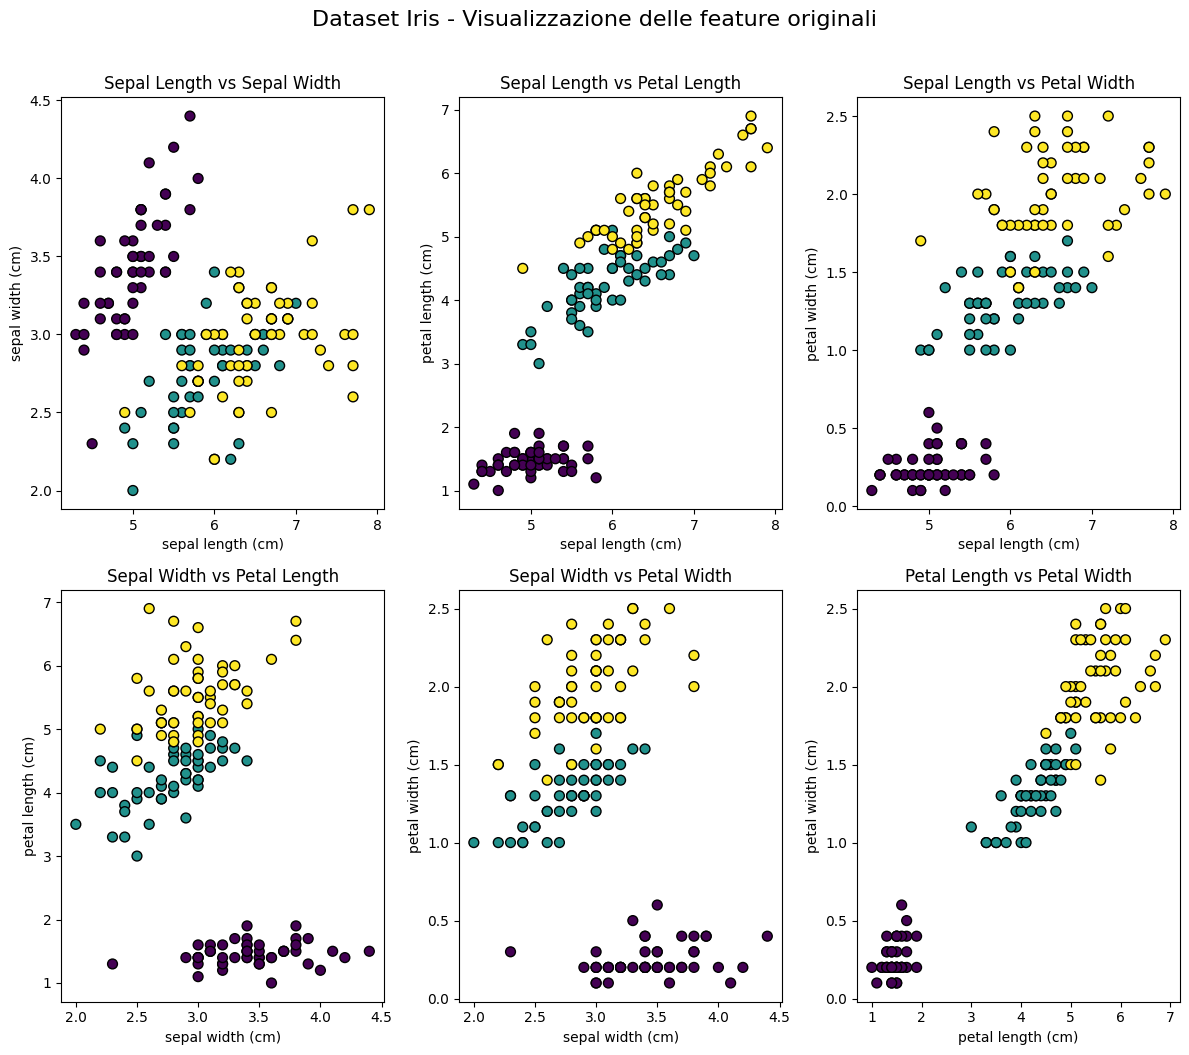


Statistiche descrittive per specie:
           sepal length (cm)                                              \
                       count   mean       std  min    25%  50%  75%  max   
species                                                                    
setosa                  50.0  5.006  0.352490  4.3  4.800  5.0  5.2  5.8   
versicolor              50.0  5.936  0.516171  4.9  5.600  5.9  6.3  7.0   
virginica               50.0  6.588  0.635880  4.9  6.225  6.5  6.9  7.9   

           sepal width (cm)         ... petal length (cm)       \
                      count   mean  ...               75%  max   
species                             ...                          
setosa                 50.0  3.428  ...             1.575  1.9   
versicolor             50.0  2.770  ...             4.600  5.1   
virginica              50.0  2.974  ...             5.875  6.9   

           petal width (cm)                                            
                      count   mean   

In [18]:
# Creiamo una visualizzazione a coppie delle feature originali
plt.figure(figsize=(12, 10))

# Plot delle feature a coppie
plt.subplot(2, 3, 1)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k', s=50)
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.title('Sepal Length vs Sepal Width')

plt.subplot(2, 3, 2)
plt.scatter(X[:, 0], X[:, 2], c=y, cmap='viridis', edgecolor='k', s=50)
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[2])
plt.title('Sepal Length vs Petal Length')

plt.subplot(2, 3, 3)
plt.scatter(X[:, 0], X[:, 3], c=y, cmap='viridis', edgecolor='k', s=50)
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[3])
plt.title('Sepal Length vs Petal Width')

plt.subplot(2, 3, 4)
plt.scatter(X[:, 1], X[:, 2], c=y, cmap='viridis', edgecolor='k', s=50)
plt.xlabel(feature_names[1])
plt.ylabel(feature_names[2])
plt.title('Sepal Width vs Petal Length')

plt.subplot(2, 3, 5)
plt.scatter(X[:, 1], X[:, 3], c=y, cmap='viridis', edgecolor='k', s=50)
plt.xlabel(feature_names[1])
plt.ylabel(feature_names[3])
plt.title('Sepal Width vs Petal Width')

plt.subplot(2, 3, 6)
plt.scatter(X[:, 2], X[:, 3], c=y, cmap='viridis', edgecolor='k', s=50)
plt.xlabel(feature_names[2])
plt.ylabel(feature_names[3])
plt.title('Petal Length vs Petal Width')

plt.tight_layout()
plt.suptitle('Dataset Iris - Visualizzazione delle feature originali', fontsize=16, y=1.05)
plt.show()

# Visualizziamo anche le statistiche delle feature per ogni specie
print("\nStatistiche descrittive per specie:")
print(iris_df.groupby('species').describe())

### Parte 2: Applicazione di PCA

##### Standardizziamo i dati prima di applicare PCA (importante!)


In [41]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Applichiamo PCA con 2 componenti
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Applichiamo PCA manuale
X_pca_manual, W_manual, var_manual = pca_from_scratch(X_scaled, 2)

# Creiamo un DataFrame con i risultati
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['species'] = [target_names[i] for i in y]

print("\nDimensioni dopo PCA:", X_pca.shape)
print("Prime 5 righe dopo la trasformazione PCA:")
print(pca_df.head())

# Confronto tra PCA con scikit e PCA manuale
# Componenti PCA: direzioni del nuovo sistema di riferimento che massimizzano la varianza
print(pca.components_)
print(W_manual.T)
#Valori di varianza spiegata da ogni piano
print(pca.explained_variance_ratio_)
print(var_manual[:2])


Dimensioni dopo PCA: (150, 2)
Prime 5 righe dopo la trasformazione PCA:
        PC1       PC2 species
0 -2.264703  0.480027  setosa
1 -2.080961 -0.674134  setosa
2 -2.364229 -0.341908  setosa
3 -2.299384 -0.597395  setosa
4 -2.389842  0.646835  setosa
[[ 0.52106591 -0.26934744  0.5804131   0.56485654]
 [ 0.37741762  0.92329566  0.02449161  0.06694199]]
[[ 0.52106591 -0.26934744  0.5804131   0.56485654]
 [-0.37741762 -0.92329566 -0.02449161 -0.06694199]]
[0.72962445 0.22850762]
[0.72962445 0.22850762]


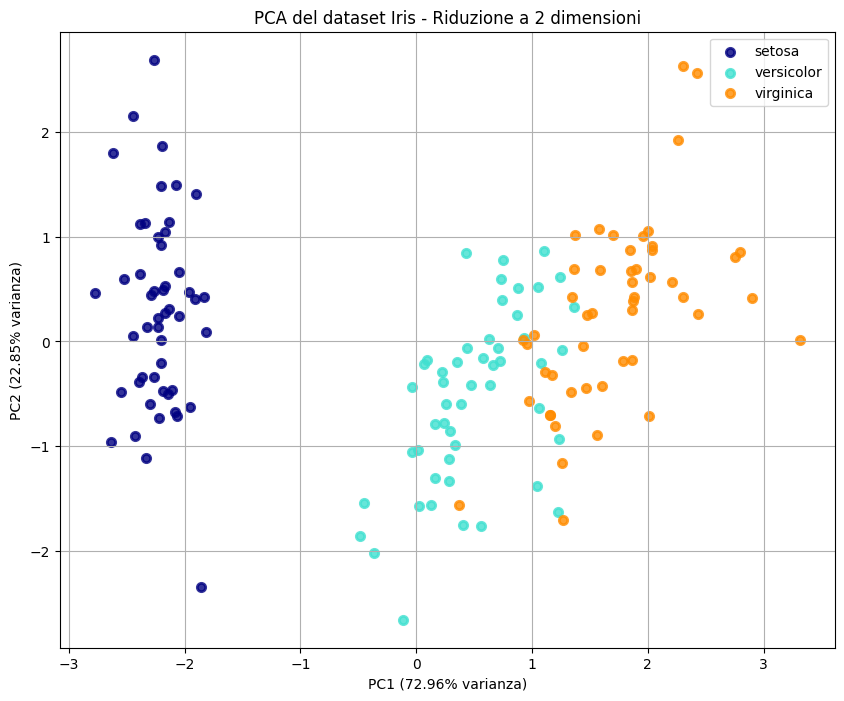

In [42]:
plt.figure(figsize=(10, 8))
colors = ['navy', 'turquoise', 'darkorange']
for i, color in enumerate(colors):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], 
                color=color, alpha=0.8, lw=2,
                label=target_names[i])
plt.legend(loc='best')
plt.title('PCA del dataset Iris - Riduzione a 2 dimensioni')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} varianza)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} varianza)')
plt.grid(True)
plt.show()

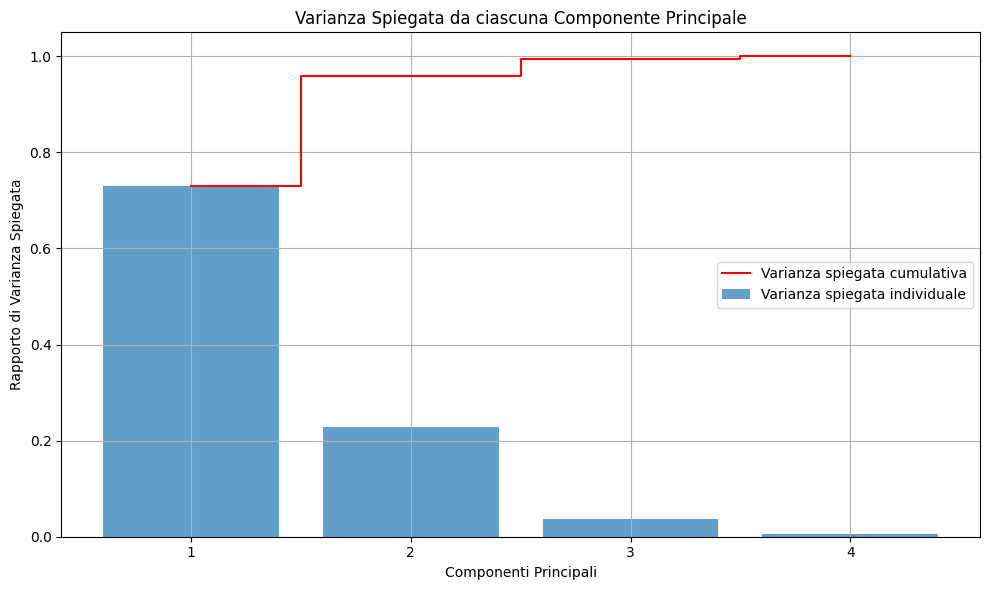

In [43]:
# Creiamo un PCA completo per vedere la varianza di tutti i componenti
pca_full = PCA()
pca_full.fit(X_scaled)

# Visualizziamo la varianza spiegata da ciascun componente
plt.figure(figsize=(10, 6))
plt.bar(range(1, 5), pca_full.explained_variance_ratio_, alpha=0.7, align='center',
        label='Varianza spiegata individuale')
plt.step(range(1, 5), np.cumsum(pca_full.explained_variance_ratio_), where='mid',
         label='Varianza spiegata cumulativa', color='red')
plt.xlabel('Componenti Principali')
plt.ylabel('Rapporto di Varianza Spiegata')
plt.title('Varianza Spiegata da ciascuna Componente Principale')
plt.legend(loc='best')
plt.grid(True)
plt.xticks(range(1, 5))
plt.tight_layout()
plt.show()

### Interpretazione dei Grafici PCA per il Dataset Iris

## Grafico 1: Varianza Spiegata (Scree Plot)

Questo grafico mostra quanto "informazione" viene catturata da ciascun componente principale:

- **Barre blu (Varianza spiegata individuale)**:
  - Componente 1: Cattura circa il 72% della varianza totale nei dati
  - Componente 2: Cattura circa il 23% della varianza
  - Componente 3: Cattura circa il 4% della varianza
  - Componente 4: Cattura meno dell'1% della varianza

- **Linea rossa (Varianza spiegata cumulativa)**:
  - I primi 2 componenti insieme spiegano circa il 95% della varianza totale
  - I primi 3 componenti spiegano circa il 99% della varianza

**Interpretazione pratica**: 

Questo grafico ci dice che possiamo ridurre le dimensioni da 4 a 2 perdendo solo circa il 5% dell'informazione originale. È un ottimo risultato che conferma che la riduzione della dimensionalità tramite PCA è molto efficace per questo dataset.

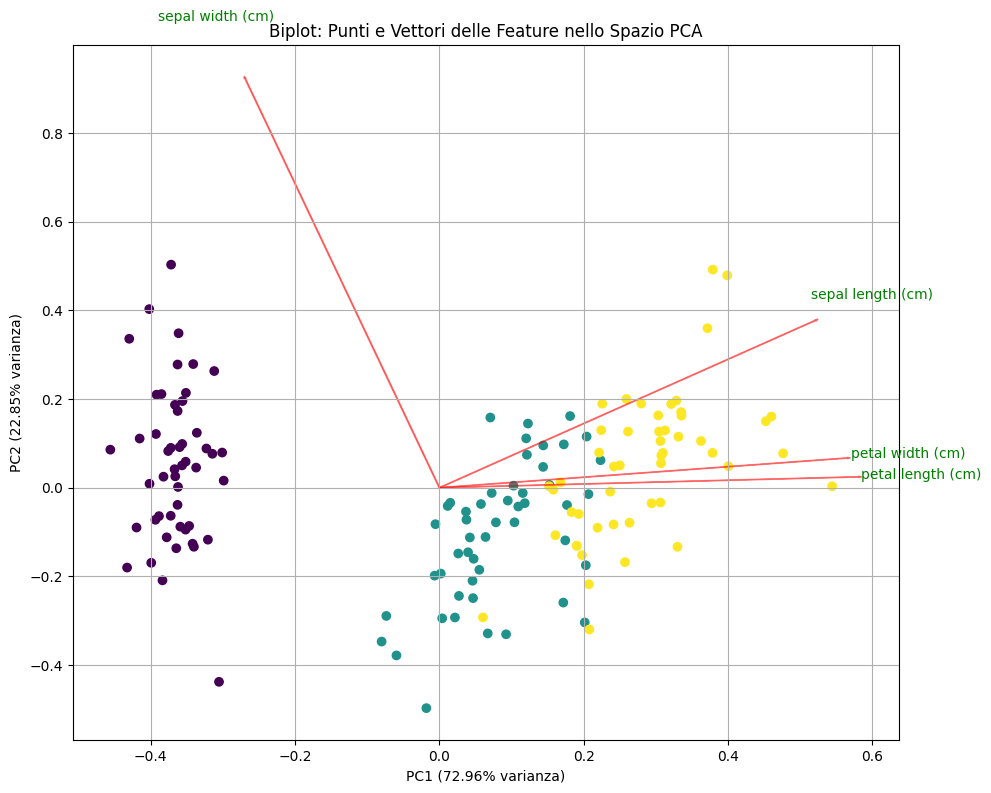

In [ ]:
# Creiamo un biplot per visualizzare contemporaneamente i punti e i vettori delle feature
def biplot(score, coef, labels=None):
    xs = score[:,0]
    ys = score[:,1]
    n = coef.shape[0]
    scalex = 1.0/(xs.max() - xs.min())
    scaley = 1.0/(ys.max() - ys.min())
    plt.scatter(xs * scalex, ys * scaley, c=y, cmap='viridis')    #campioni proiettati sulle prime due componenti principali
    for i in range(n):
        plt.arrow(0, 0, coef[i,0], coef[i,1], color='r', alpha=0.5)      #la matrice V mi dice come sono mappate componenti con feature
        if labels is not None:
            plt.text(coef[i,0]* 1.15, coef[i,1] * 1.15, labels[i], color='g', ha='center', va='center')

plt.figure(figsize=(10, 8))
biplot(X_pca, pca.components_.T, feature_names)  # Nota: i components sono già trasposti
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} varianza)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} varianza)')
plt.title('Biplot: Punti e Vettori delle Feature nello Spazio PCA')
plt.grid(True)
plt.tight_layout()
plt.show()


## Grafico 2: Biplot

Questo grafico complesso mostra due informazioni contemporaneamente:

1. **Punti colorati**: Rappresentano i fiori Iris proiettati nello spazio dei primi due componenti principali:
   - Punti viola (a sinistra): Probabilmente Iris setosa
   - Punti turchesi (al centro): Probabilmente Iris versicolor
   - Punti gialli (a destra): Probabilmente Iris virginica

2. **Frecce rosse**: Rappresentano come le feature originali influenzano i componenti principali:
   - La freccia lunga verso l'alto ("sepal width"): Contribuisce fortemente al PC2 (asse y)
   - Le frecce quasi orizzontali ("petal length" e "petal width"): Contribuiscono fortemente al PC1 (asse x)
   - La freccia diagonale ("sepal length"): Contribuisce a entrambi i componenti

**Interpretazione biologica**:
- Il primo componente principale (PC1) è dominato dalle dimensioni dei petali. Questo separa chiaramente Iris setosa (petali piccoli) dalle altre due specie.
- Il secondo componente principale (PC2) è influenzato principalmente dalla larghezza dei sepali. Questo aiuta a distinguere tra Versicolor e Virginica.
- Le specie sono ben separate anche nello spazio ridotto, confermando che PCA ha mantenuto le informazioni rilevanti per la classificazione.

Questo biplot è particolarmente prezioso perché permette di vedere sia come i dati si distribuiscono nello spazio ridotto, sia come interpretare i nuovi assi in relazione alle caratteristiche originali dei fiori.

Accuratezza con feature originali: 1.0


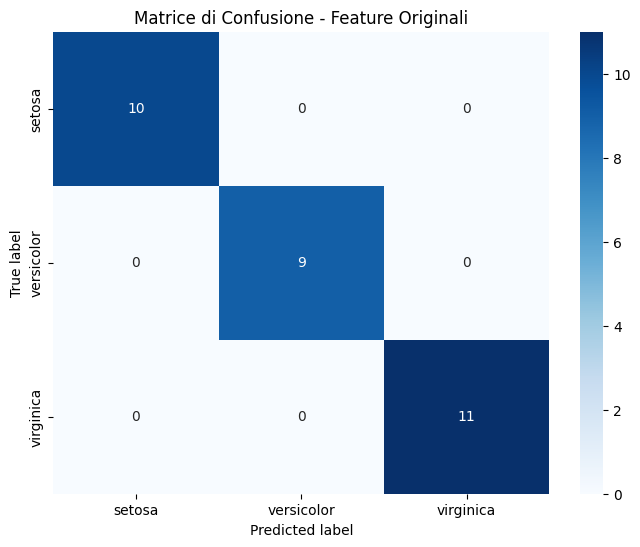

In [44]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

# Caricamento del dataset Iris
iris = load_iris()
X = iris.data
y = iris.target

# Suddividiamo in training e test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Classificatore NB con feature originali
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_orig = gnb.predict(X_test)
accuracy_orig = accuracy_score(y_test, y_pred_orig)
print("Accuratezza con feature originali:", accuracy_orig)
# Visualizzazione matrice di confusione
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
# matrice di confusione
cm = confusion_matrix(y_test, y_pred_orig)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Matrice di Confusione - Feature Originali')
plt.show()


Accuratezza dopo PCA: 0.9666666666666667


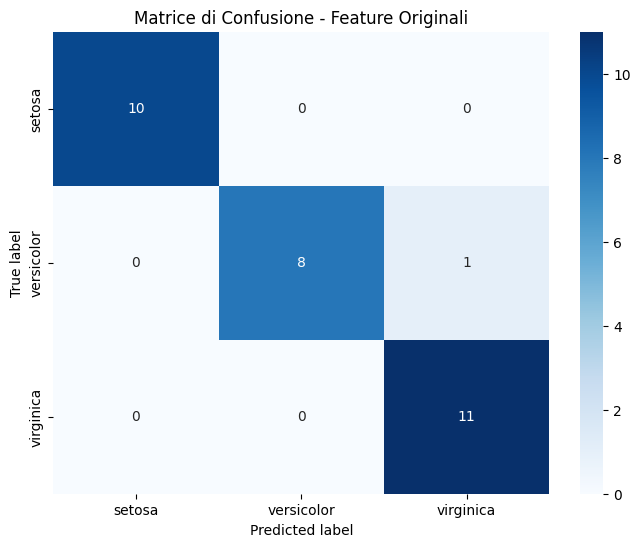

In [45]:
# Standardizziamo i dati per PCA
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Applichiamo PCA per ridurre a 2 componenti
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Classificatore NB con dati trasformati con PCA
gnb_pca = GaussianNB()
gnb_pca.fit(X_train_pca, y_train)
y_pred_pca = gnb_pca.predict(X_test_pca)
accuracy_pca = accuracy_score(y_test, y_pred_pca)
print("Accuratezza dopo PCA:", accuracy_pca)
cm = confusion_matrix(y_test, y_pred_pca)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Matrice di Confusione - Feature Originali')
plt.show()

### Esempio 2

1. Decidere quante componenti tenere

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

# Esempio con dataset di cifre scritte a mano
digits = load_digits()
X = digits.data  # 64 feature (pixel 8x8)

Componenti originali: 64
Componenti per 95% varianza: 29
Riduzione: 35 componenti (54.7%)


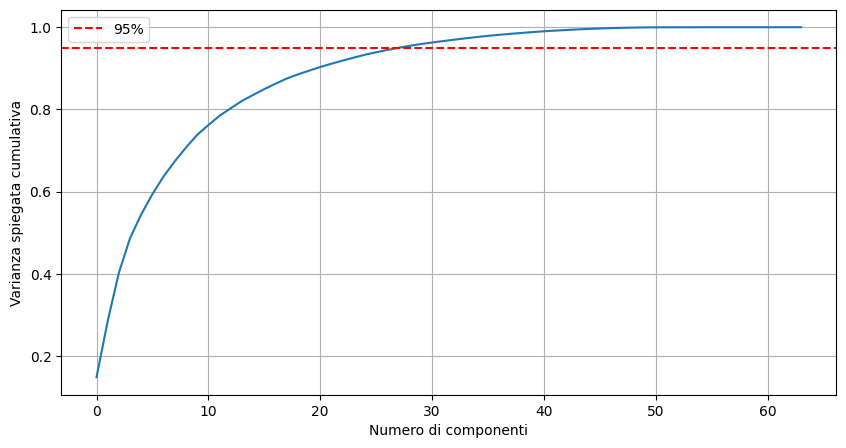

In [47]:
# PCA completo
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(X)

# Visualizziamo la varianza spiegata
plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Numero di componenti')
plt.ylabel('Varianza spiegata cumulativa')
plt.axhline(y=0.95, color='r', linestyle='--', label='95%')
plt.grid(True)
plt.legend()


# Quante componenti per il 95% della varianza?
n_components_95 = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1
print(f"Componenti originali: 64")
print(f"Componenti per 95% varianza: {n_components_95}")
print(f"Riduzione: {64-n_components_95} componenti ({(64-n_components_95)/64:.1%})")

In [48]:
# Confrontiamo diverse soglie di varianza
thresholds = [0.80, 0.90, 0.95, 0.99]
results = []

for threshold in thresholds:
    n_comp = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= threshold) + 1
    compression_ratio = n_comp / X.shape[1]
    results.append({
        'threshold': threshold,
        'n_components': n_comp,
        'Percentuale componenti tenute': f"{compression_ratio:.1%}",
        'info_kept': f"{threshold:.0%}"
    })

import pandas as pd
df_results = pd.DataFrame(results)
print(df_results)

   threshold  n_components Percentuale componenti tenute info_kept
0       0.80            13                         20.3%       80%
1       0.90            21                         32.8%       90%
2       0.95            29                         45.3%       95%
3       0.99            41                         64.1%       99%


### Vediamo come la PCA rappresenta e ricostruisce una immagine

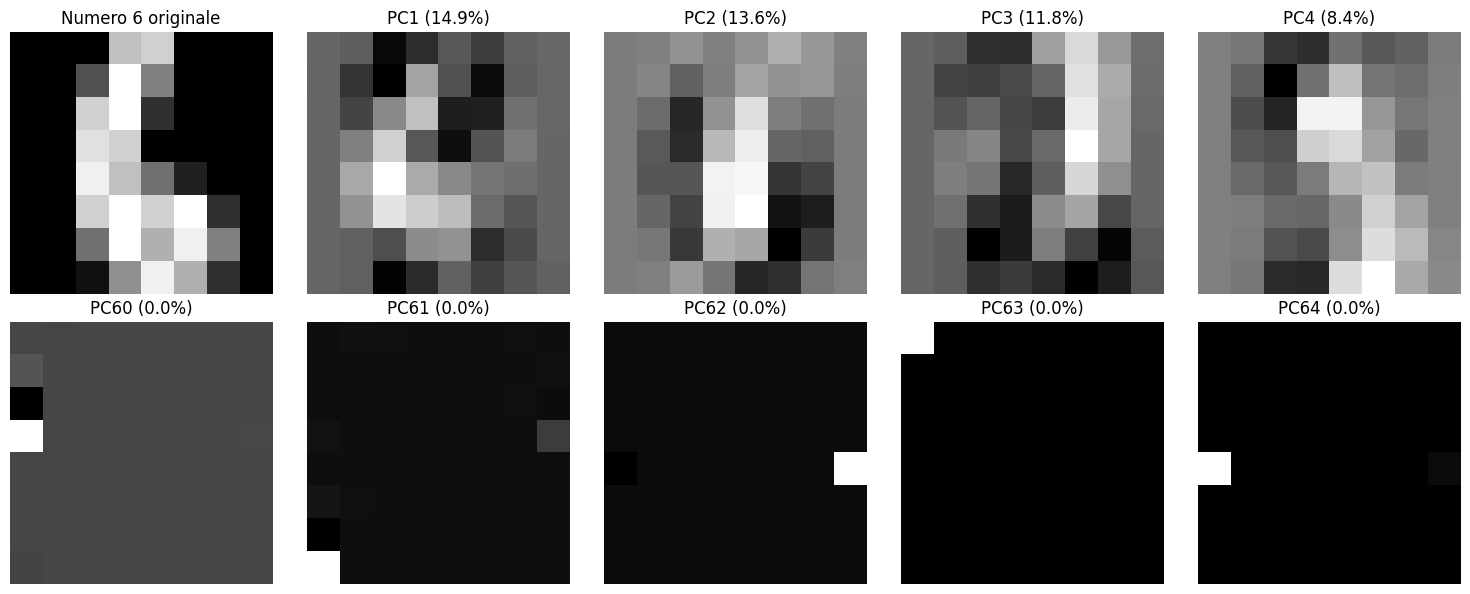

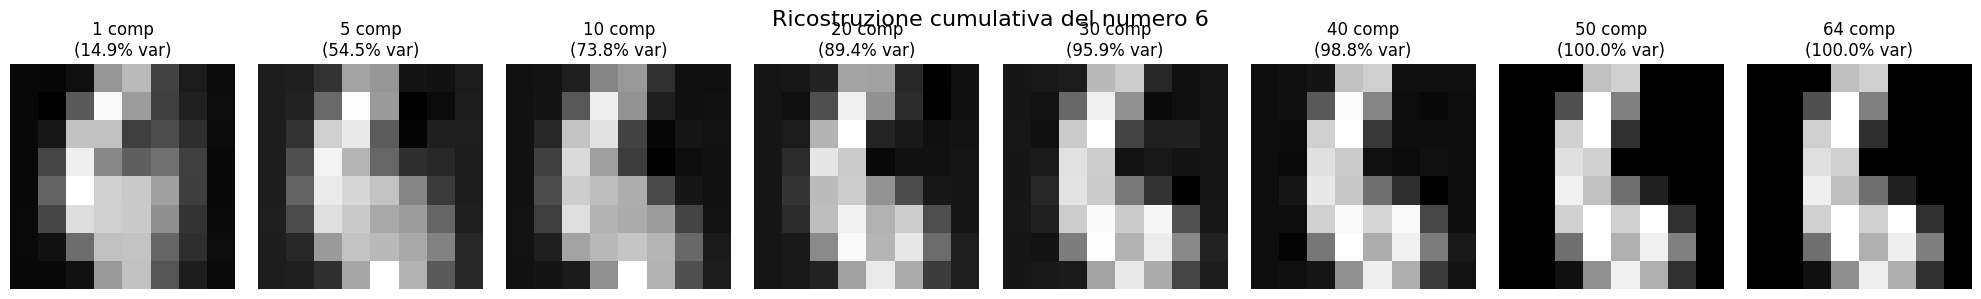

In [ ]:

# Trova il primo esempio del numero 6
idx_6 = np.where(digits.target == 6)[0][0]
digit_6 = X[idx_6]

# PCA
pca = PCA()
pca.fit(X)
X_transformed = pca.transform(X)

# Visualizzazione
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

# Numero 6 originale
axes[0].imshow(digit_6.reshape(8, 8), cmap='gray')
axes[0].set_title('Numero 6 originale')
axes[0].axis('off')

# Prime 4 componenti
for i in range(4):
    axes[i+1].imshow(pca.components_[i].reshape(8, 8), cmap='gray')
    axes[i+1].set_title(f'PC{i+1} ({pca.explained_variance_ratio_[i]:.1%})')
    axes[i+1].axis('off')

# Ultime 5 componenti
for i in range(5):
    pc_idx = 59 + i  # PC61, PC62, PC63, PC64
    axes[i+5].imshow(pca.components_[pc_idx].reshape(8, 8), cmap='gray')
    axes[i+5].set_title(f'PC{pc_idx+1} ({pca.explained_variance_ratio_[pc_idx]:.1%})')
    axes[i+5].axis('off')

plt.tight_layout()
plt.show()

# Ricostruzione cumulativa del numero 6
n_components_list = [1, 5, 10, 20, 30, 40, 50, 64]
fig, axes = plt.subplots(1, len(n_components_list), figsize=(20, 3))

mean_image = pca.mean_.reshape(8, 8)

for i, n_comp in enumerate(n_components_list):
    # Ricostruisci con n_comp componenti
    reconstruction = pca.mean_.copy()
    for j in range(n_comp):
        reconstruction += X_transformed[idx_6, j] * pca.components_[j]
    
    axes[i].imshow(reconstruction.reshape(8, 8), cmap='gray')
    axes[i].set_title(f'{n_comp} comp\n({np.sum(pca.explained_variance_ratio_[:n_comp]):.1%} var)')
    axes[i].axis('off')

plt.suptitle('Ricostruzione cumulativa del numero 6', fontsize=16)
plt.tight_layout()
plt.show()

# 4 - Manifold Learning

### Step 1: Definizione matematica di manifold

  

Un manifold d-dimensionale in uno spazio n-dimensionale (con $d$ < $n$) è un insieme di punti che localmente assomiglia a uno spazio euclideo $ℝ^d$.

  

Formalmente: per ogni punto $p$ sul manifold, esiste un intorno $U$ di $p$ e una mappa continua e invertibile $φ: U → ℝ^d$.

  

### Intuizione geometrica

  

Per comprendere intuitivamente:

  

- Una linea curva è un manifold 1D in uno spazio 2D

- La superficie di una sfera è un manifold 2D in uno spazio 3D

- La superficie di uno "Swiss roll" è un manifold 2D "arrotolato" in uno spazio 3D

  

### L'ipotesi del manifold

  

L'ipotesi fondamentale afferma che:

  

- I dati del mondo reale, nonostante l'alta dimensionalità apparente, giacciono spesso su o vicino a manifold di dimensionalità molto inferiore

- La variabilità significativa nei dati avviene lungo le dimensioni del manifold

  

Esempi:

  

- Il set di tutte le possibili immagini di volti umani forma un manifold di dimensionalità relativamente bassa nello spazio di tutte le immagini possibili

- I segnali vocali formano manifold di bassa dimensionalità negli spazi delle frequenze

  
  

### Proprietà locali vs globali

  

Caratteristica chiave dei manifold:

  

- Localmente sembrano spazi euclidei (come piani)

- Globalmente possono avere topologie complesse (curve, pieghe, avvolgimenti)

  

Questo è il motivo per cui proiezioni lineari globali (come PCA) spesso falliscono con manifold complessi.

  

### Approcci al manifold learning

  

Gli algoritmi di manifold learning cercano di:

  

1. Scoprire la struttura intrinseca del manifold

2. Trovare una rappresentazione che preservi proprietà importanti come:

    - Distanze geodetiche (lungo il manifold)

    - Relazioni di vicinanza tra punti

    - Topologia globale

  

Text(0.5, 1.0, 'Proiezione su piano x-y')

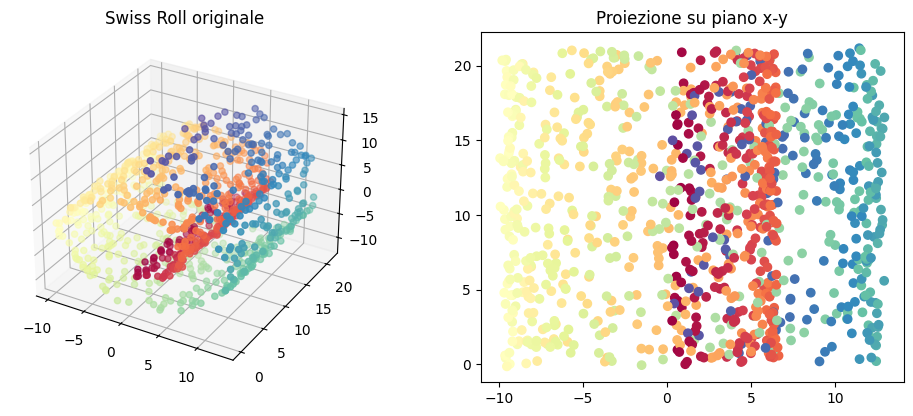

In [49]:
from sklearn.datasets import make_swiss_roll

X, color = make_swiss_roll(n_samples=1000, noise=0.2, random_state=42)


# Visualizzazione 3D

fig = plt.figure(figsize=(12, 10))

  

# Swiss roll originale

ax = fig.add_subplot(221, projection='3d')

ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=color, cmap=plt.cm.Spectral)

ax.set_title('Swiss Roll originale')

  

# Proiezione semplice (eliminando una dimensione)

ax = fig.add_subplot(222)

ax.scatter(X[:, 0], X[:, 1], c=color, cmap=plt.cm.Spectral)

ax.set_title('Proiezione su piano x-y')

##

## 4.1 LLE - Locally Linear Embedding

#### **Idea Fondamentale**: Anche se un manifold può essere globalmente non lineare, localmente (in piccoli intorni) può essere approssimato come lineare.

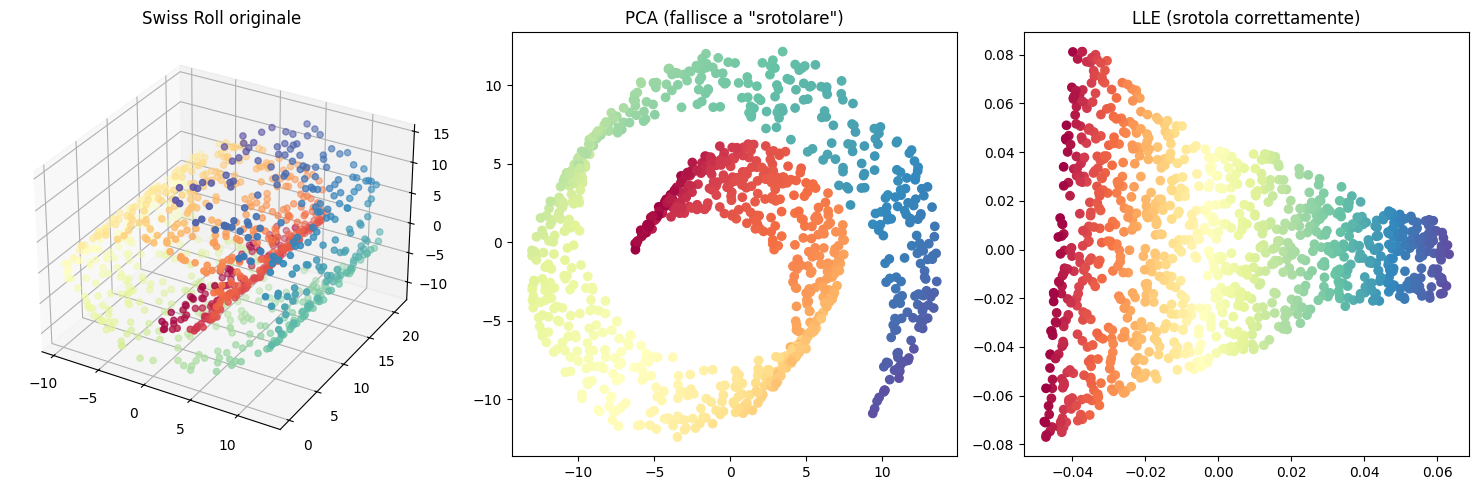

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import LocallyLinearEmbedding
from sklearn.decomposition import PCA

# Generiamo il Swiss Roll
n_samples = 1000
X, color = make_swiss_roll(n_samples=n_samples, noise=0.1, random_state=42)

# Visualizziamo il problema
fig = plt.figure(figsize=(15, 5))

# Swiss roll originale
ax = fig.add_subplot(131, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=color, cmap=plt.cm.Spectral)
ax.set_title('Swiss Roll originale')

# PCA fallisce
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
ax = fig.add_subplot(132)
ax.scatter(X_pca[:, 0], X_pca[:, 1], c=color, cmap=plt.cm.Spectral)
ax.set_title('PCA (fallisce a "srotolare")')

# LLE riesce
lle = LocallyLinearEmbedding(n_components=2, n_neighbors=12, random_state=42)
X_lle = lle.fit_transform(X)
ax = fig.add_subplot(133)
ax.scatter(X_lle[:, 0], X_lle[:, 1], c=color, cmap=plt.cm.Spectral)
ax.set_title('LLE (srotola correttamente)')

plt.tight_layout()
plt.show()

### 4.1.0 - I 4 Steps di LLE

#### 4.1.1 - Step 1: Trovo i k vicini più prossimi

Per ogni punto $x^{(i)}$, LLE trova i suoi k vicini più prossimi usando la distanza euclidea.

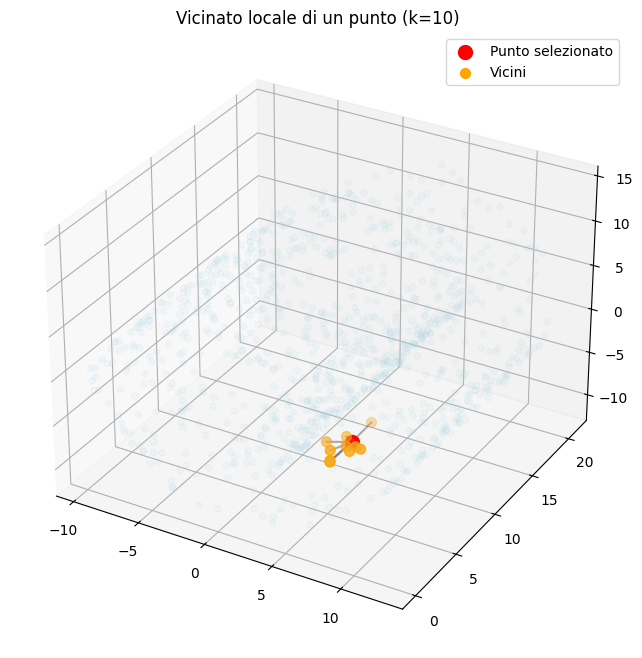

In [51]:
# Visualizziamo i vicini per un punto specifico
from sklearn.neighbors import NearestNeighbors

# Scegliamo un punto
point_idx = 500
point = X[point_idx]

# Troviamo i k vicini
k = 10
nbrs = NearestNeighbors(n_neighbors=k+1).fit(X)
distances, indices = nbrs.kneighbors([point])
neighbor_indices = indices[0][1:]  # Escludiamo il punto stesso

# Visualizziamo
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c='lightblue', alpha=0.1)
ax.scatter(point[0], point[1], point[2], c='red', s=100, label='Punto selezionato')
ax.scatter(X[neighbor_indices, 0], X[neighbor_indices, 1], X[neighbor_indices, 2], 
           c='orange', s=50, label='Vicini')

# Disegniamo le connessioni
for neighbor_idx in neighbor_indices:
    ax.plot([point[0], X[neighbor_idx, 0]], 
            [point[1], X[neighbor_idx, 1]], 
            [point[2], X[neighbor_idx, 2]], 'k-', alpha=0.3)

ax.set_title(f'Vicinato locale di un punto (k={k})')
ax.legend()
plt.show()

#### 4.1.2 - Step 2: Ricostruzione lineare locale


LLE esprime ogni punto come combinazione lineare dei suoi vicini:

$$x^{(i)} \approx \sum_{j=1}^{m} w_{i,j} x^{(j)}$$

I pesi $w_{i,j}$ sono trovati minimizzando l'errore di ricostruzione:

$$\min_W \sum_{i=1}^{m} \left| x^{(i)} - \sum_{j=1}^{m} w_{i,j} x^{(j)} \right|^2$$

con i vincoli:

- $w_{i,j} = 0$ se $x^{(j)}$ non è uno dei k vicini più prossimi di $x^{(i)}$
- $\sum_{j=1}^{m} w_{i,j} = 1$ per ogni $i$ (normalizzazione)

Dove:

- $m$ è il numero totale di training instances
- $W$ è la matrice dei pesi contenente tutti i $w_{i,j}$
- La norma $|\cdot|$ indica la norma euclidea

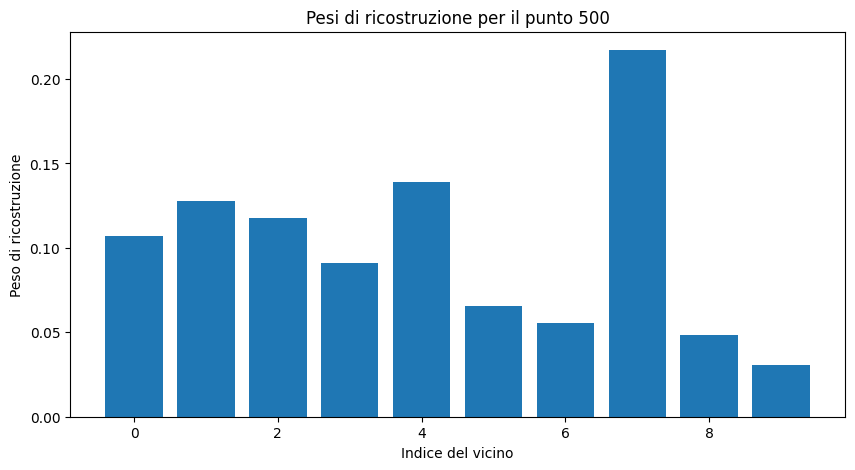

Errore di ricostruzione: 0.004623


In [52]:
# Implementiamo il calcolo dei pesi di ricostruzione per un punto
def compute_reconstruction_weights(X, point_idx, neighbor_indices, reg=1e-3):
    """Calcola i pesi di ricostruzione per un punto dato i suoi vicini."""
    k = len(neighbor_indices)
    
    # Matrice dei vicini centrata rispetto al punto
    Z = X[neighbor_indices] - X[point_idx]
    
    # Matrice di covarianza locale
    C = np.dot(Z, Z.T)    #ci serve per capire la forma locale
    
    # Regolarizzazione per stabilità numerica
    C += reg * np.eye(k) * np.trace(C)
    
    # Risolviamo il sistema lineare
    weights = np.linalg.solve(C, np.ones(k))
    
    # Normalizziamo
    weights /= weights.sum()
    
    return weights

# Calcoliamo i pesi per il nostro punto esempio
weights = compute_reconstruction_weights(X, point_idx, neighbor_indices)

# Visualizziamo i pesi
plt.figure(figsize=(10, 5))
plt.bar(range(len(weights)), weights)
plt.xlabel('Indice del vicino')
plt.ylabel('Peso di ricostruzione')
plt.title(f'Pesi di ricostruzione per il punto {point_idx}')
plt.show()

# Verifichiamo la ricostruzione
reconstruction = np.sum(X[neighbor_indices] * weights[:, np.newaxis], axis=0)
reconstruction_error = np.linalg.norm(X[point_idx] - reconstruction)
print(f"Errore di ricostruzione: {reconstruction_error:.6f}")

#### 4.1.2 - Step 3: Trovare l'embedding a bassa dimensionalità

Una volta trovati tutti i pesi $\hat{w}_{i,j}$, LLE cerca una rappresentazione a bassa dimensionalità che preservi queste relazioni locali.

Se $z^{(i)}$ è l'immagine di $x^{(i)}$ nello spazio d-dimensionale (dove $d < n$), vogliamo:

$$z^{(i)} \approx \sum_{j=1}^{m} \hat{w}_{i,j} z^{(j)}$$

Questo porta al problema di ottimizzazione non vincolato:

$$\min_Z \sum_{i=1}^{m} \left| z^{(i)} - \sum_{j=1}^{m} \hat{w}_{i,j} z^{(j)} \right|^2$$

Dove:

- $Z$ è la matrice contenente tutti i $z^{(i)}$
- $\hat{w}_{i,j}$ sono i pesi fissi trovati nello step precedente
- La soluzione viene trovata risolvendo un problema agli autovalori generalizzato

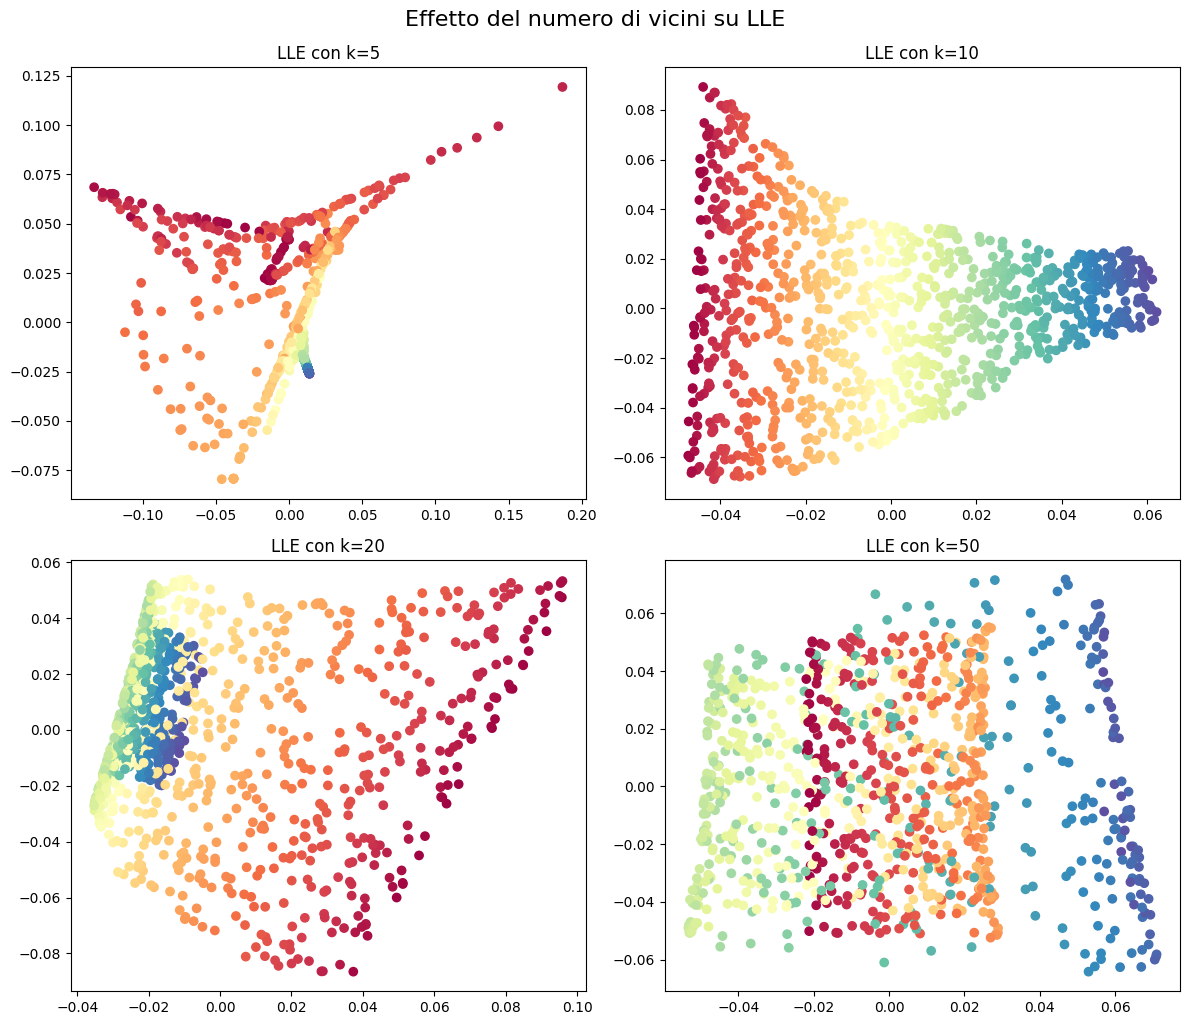

In [53]:
# Confrontiamo diverse scelte di k (numero di vicini)
k_values = [5, 10, 20, 50]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, k in enumerate(k_values):
    lle = LocallyLinearEmbedding(n_components=2, n_neighbors=k, random_state=42)
    X_lle = lle.fit_transform(X)
    
    axes[idx].scatter(X_lle[:, 0], X_lle[:, 1], c=color, cmap=plt.cm.Spectral)
    axes[idx].set_title(f'LLE con k={k}')
    
plt.tight_layout()
plt.suptitle('Effetto del numero di vicini su LLE', fontsize=16, y=1.02)
plt.show()

### Impatto di k

Nel LLE, il parametro `k` controlla quanti vicini locali vengono usati per ricostruire ogni punto.  

Con `k` troppo piccolo, la struttura locale è instabile e il manifold può frammentarsi; con `k` troppo grande, l’algoritmo perde la località e tende a deformare o “appiattire” la struttura non lineare.  

Un valore intermedio di `k` permette di preservare correttamente la geometria locale del manifold.

### 4.2 Implementiamo LLE da zero

In [55]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
from scipy.sparse.linalg import eigsh
from scipy.linalg import eigh

def lle_from_scratch(X, n_components=2, n_neighbors=10, reg=1e-3):
    """
    Implementazione robusta di Locally Linear Embedding da zero.
    """
    n_samples = X.shape[0]
    
    # Step 1: Trova i k vicini più prossimi per ogni punto
    print("Step 1: Trovando i vicini più prossimi...")
    nbrs = NearestNeighbors(n_neighbors=n_neighbors+1).fit(X)
    distances, indices = nbrs.kneighbors(X)
    
    # Step 2: Calcola i pesi di ricostruzione locale
    print("Step 2: Calcolando i pesi di ricostruzione...")
    W = np.zeros((n_samples, n_samples))
    
    for i in range(n_samples):
        neighbors_idx = indices[i, 1:]  
        Xi = X[i]
        neighbors = X[neighbors_idx]
        Z = neighbors - Xi  
        
        # Calcola la matrice di covarianza locale
        C = Z @ Z.T
        
        # Aggiungi regolarizzazione per stabilità numerica
        trace = np.trace(C)
        if trace > 0:
            reg_term = reg * trace
        else:
            reg_term = reg
        C = C + reg_term * np.eye(n_neighbors)
        
        # Risolvi il sistema lineare per trovare i pesi
        try:
            weights = np.linalg.solve(C, np.ones(n_neighbors))
        except np.linalg.LinAlgError:
            weights = np.linalg.pinv(C) @ np.ones(n_neighbors)
        
        # Normalizza i pesi
        weights = weights / np.sum(weights)
        W[i, neighbors_idx] = weights
    
    # Step 3: Trova l'embedding a bassa dimensionalità
    print("Step 3: Calcolando l'embedding...")
    
    # Costruisci la matrice M = (I - W)^T(I - W)
    I = np.eye(n_samples)
    M = (I - W).T @ (I - W)
    
    # Aggiungi una piccola regolarizzazione per stabilità numerica
    M = M + reg * np.eye(n_samples) * np.trace(M)
    
    # Usa eigh invece di eigsh per maggiore stabilità
    eigenvalues, eigenvectors = eigh(M)
    
    # Ordina per autovalori crescenti
    idx = np.argsort(eigenvalues)
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    
    # Prendi gli autovettori corrispondenti agli autovalori più piccoli (escluso il primo che è ~0)
    # Skip the first eigenvector (corresponding to eigenvalue ~0)
    embedding = eigenvectors[:, 1:n_components+1]
    
    # Normalizza l'embedding
    embedding = embedding * np.sqrt(n_samples)
    
    return embedding

Applicando LLE implementato da zero...
Step 1: Trovando i vicini più prossimi...
Step 2: Calcolando i pesi di ricostruzione...
Step 3: Calcolando l'embedding...


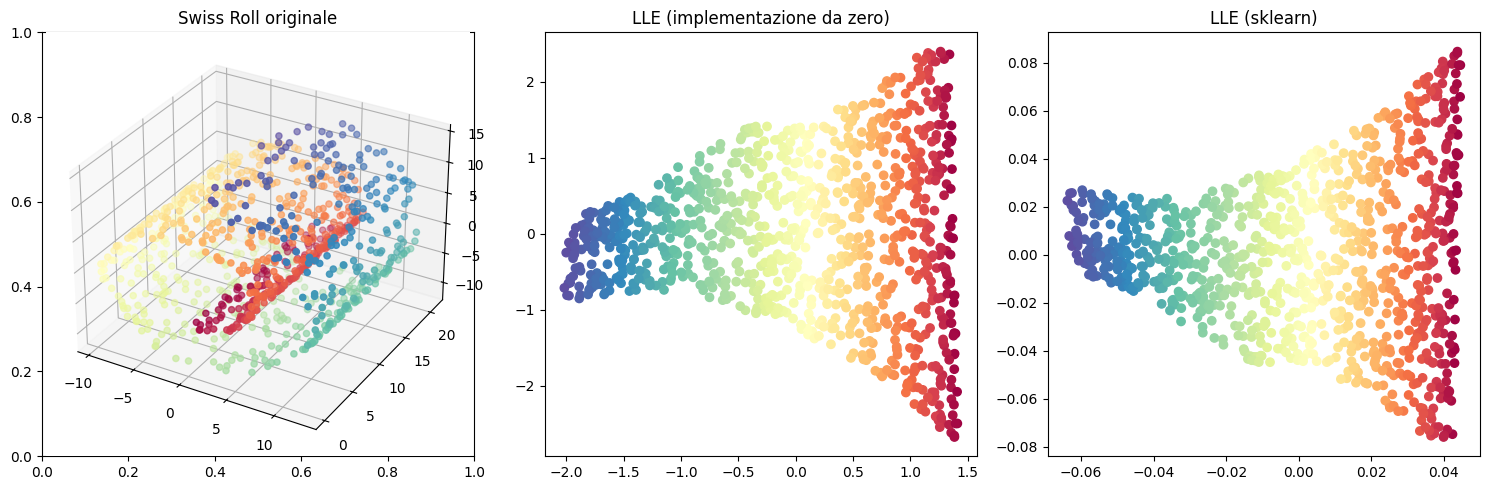

In [56]:
from sklearn.datasets import make_swiss_roll
import matplotlib.pyplot as plt

# Genera Swiss roll
n_samples = 1000
X, color = make_swiss_roll(n_samples=n_samples, noise=0.05, random_state=42)

# Applica LLE implementato da zero
print("Applicando LLE implementato da zero...")
X_lle_scratch = lle_from_scratch(X, n_components=2, n_neighbors=12, reg=1e-3)

# Confronta con sklearn
from sklearn.manifold import LocallyLinearEmbedding
lle_sklearn = LocallyLinearEmbedding(n_components=2, n_neighbors=12, reg=1e-3)
X_lle_sklearn = lle_sklearn.fit_transform(X)

# Visualizza i risultati
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Dati originali
ax = fig.add_subplot(131, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=color, cmap=plt.cm.Spectral)
ax.set_title('Swiss Roll originale')

# LLE implementato da zero
axes[1].scatter(X_lle_scratch[:, 0], X_lle_scratch[:, 1], c=color, cmap=plt.cm.Spectral)
axes[1].set_title('LLE (implementazione da zero)')

# LLE sklearn
axes[2].scatter(X_lle_sklearn[:, 0], X_lle_sklearn[:, 1], c=color, cmap=plt.cm.Spectral)
axes[2].set_title('LLE (sklearn)')

plt.tight_layout()
plt.show()

### 4.3 - Confronto fra LLE e PCA

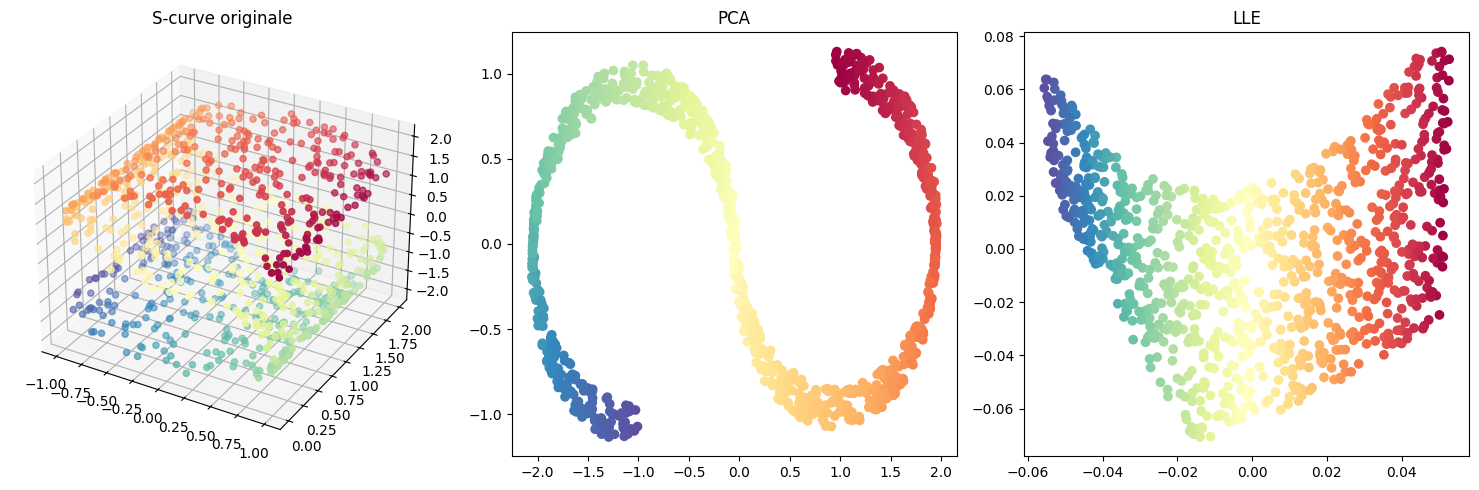

In [38]:
# Creiamo un dataset con una struttura più complessa
from sklearn.datasets import make_s_curve

n_points = 1000
X_s, color_s = make_s_curve(n_points, random_state=42)

# Confronto su S-curve
fig = plt.figure(figsize=(15, 5))

# Dati originali
ax = fig.add_subplot(131, projection='3d')
ax.scatter(X_s[:, 0], X_s[:, 1], X_s[:, 2], c=color_s, cmap=plt.cm.Spectral)
ax.set_title('S-curve originale')

# PCA
pca = PCA(n_components=2)
X_s_pca = pca.fit_transform(X_s)
ax = fig.add_subplot(132)
ax.scatter(X_s_pca[:, 0], X_s_pca[:, 1], c=color_s, cmap=plt.cm.Spectral)
ax.set_title('PCA')

# LLE
lle = LocallyLinearEmbedding(n_components=2, n_neighbors=12, random_state=42)
X_s_lle = lle.fit_transform(X_s)
ax = fig.add_subplot(133)
ax.scatter(X_s_lle[:, 0], X_s_lle[:, 1], c=color_s, cmap=plt.cm.Spectral)
ax.set_title('LLE')

plt.tight_layout()
plt.show()

### PCA vs LLE sulla S-Curve

In questo esempio, **LLE** riesce a rappresentare meglio la struttura originale dei dati rispetto alla **PCA**.  
La PCA applica una proiezione lineare sul piano 2D: preserva la varianza globale, ma non riesce a “srotolare” la forma non lineare della S-curve, causando sovrapposizioni e distorsioni geometriche.  

LLE invece preserva le relazioni locali tra punti vicini e riesce quindi a mantenere la struttura del manifold, producendo una rappresentazione 2D più fedele alla geometria originale della superficie.

In [ ]:
# Applichiamo LLE al dataset delle cifre
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Carichiamo il dataset
digits = load_digits()
X_digits = digits.data
y_digits = digits.target

indices = np.arange(len(X_digits))

# Split dei dati mantenendo gli indici
# LLE costruisce l’embedding mantenendo le relazioni locali tra i punti del dataset.  
# Quando si applica `train_test_split`, i campioni vengono mescolati: quindi i primi elementi di `X_all_lle` non corrispondono necessariamente ai campioni di `X_train`.
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_digits, y_digits, indices, test_size=0.2, random_state=42, stratify=y_digits)

# Confrontiamo le performance con e senza riduzione dimensionale
# 1. Classificatore sui dati originali
knn_original = KNeighborsClassifier(n_neighbors=5)
knn_original.fit(X_train, y_train)
acc_original = accuracy_score(y_test, knn_original.predict(X_test))

# 2. PCA
pca = PCA(n_components=30)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
knn_pca = KNeighborsClassifier(n_neighbors=5)
knn_pca.fit(X_train_pca, y_train)
acc_pca = accuracy_score(y_test, knn_pca.predict(X_test_pca))

# 3. LLE
lle = LocallyLinearEmbedding(n_components=30, n_neighbors=10)
X_train_lle = lle.fit_transform(X_train)
# Nota IMPORTANTE: LLE non può trasformare nuovi dati!
# Dobbiamo addestrare su tutto il dataset
lle_full = LocallyLinearEmbedding(n_components=30, n_neighbors=10)
X_all_lle = lle_full.fit_transform(X_digits)
X_train_lle = X_all_lle[idx_train]
X_test_lle = X_all_lle[idx_test]

knn_lle = KNeighborsClassifier(n_neighbors=5)
knn_lle.fit(X_train_lle, y_train)
acc_lle = accuracy_score(y_test, knn_lle.predict(X_test_lle))

print(f"Accuratezza dati originali (64D): {acc_original:.3f}")
print(f"Accuratezza con PCA (30D): {acc_pca:.3f}")
print(f"Accuratezza con LLE (30D): {acc_lle:.3f}")

Accuratezza dati originali (64D): 0.983
Accuratezza con PCA (30D): 0.981
Accuratezza con LLE (30D): 0.972


## PCA vs LLE: riduzione di feature vs embedding del manifold

Sia PCA che LLE sono tecniche di dimensionality reduction, ma hanno obiettivi e proprietà molto diverse.

### PCA: trasformazione generale delle feature
La PCA apprende una trasformazione lineare esplicita:

$$
X_{reduced} = XW
$$

dove $W$ contiene le componenti principali.  
Una volta appresa, questa trasformazione può essere applicata a nuovi dati (`transform`), rendendo la PCA adatta a:
- preprocessing in pipeline ML,
- compressione delle feature,
- riduzione del rumore,
- deployment e inferenza su nuovi campioni.

### LLE: embedding non lineare dei dati osservati
LLE non apprende una trasformazione generale, ma costruisce un embedding preservando le relazioni locali tra i punti del dataset.  
L’embedding dipende direttamente dal grafo dei vicini e dalla struttura del dataset utilizzato durante il fit.

Per questo motivo:
- LLE è molto efficace per visualizzare manifold non lineari,
- ma non è naturalmente adatto alla trasformazione di nuovi dati,
- e può introdurre *data leakage* se applicato all’intero dataset prima dello split train/test.

### In pratica
- **PCA** → feature reduction utilizzabile operativamente in ML.
- **LLE** → strumento esplorativo per analisi geometrica e visualizzazione di manifold non lineari.

### 4.4 Limitazioni di LLE e soluzioni

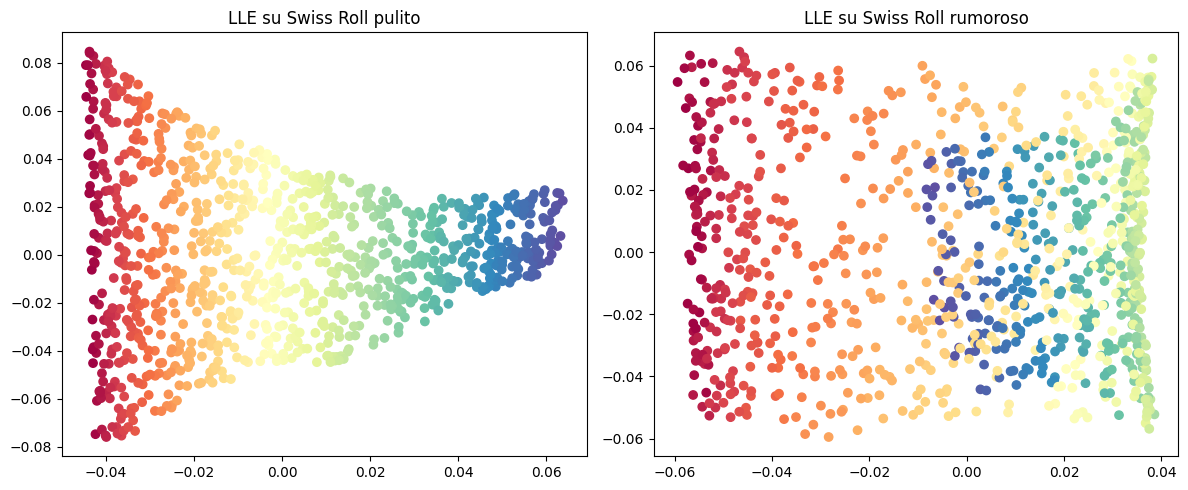

In [59]:
# Problema: LLE è sensibile al rumore
X_noisy = X + np.random.normal(0, 0.5, X.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# LLE su dati puliti
lle_clean = LocallyLinearEmbedding(n_components=2, n_neighbors=12)
X_lle_clean = lle_clean.fit_transform(X)
axes[0].scatter(X_lle_clean[:, 0], X_lle_clean[:, 1], c=color, cmap=plt.cm.Spectral)
axes[0].set_title('LLE su Swiss Roll pulito')

# LLE su dati rumorosi
lle_noisy = LocallyLinearEmbedding(n_components=2, n_neighbors=12)
X_lle_noisy = lle_noisy.fit_transform(X_noisy)
axes[1].scatter(X_lle_noisy[:, 0], X_lle_noisy[:, 1], c=color, cmap=plt.cm.Spectral)
axes[1].set_title('LLE su Swiss Roll rumoroso')

plt.tight_layout()
plt.show()

### Riepilogo: Quando usare PCA vs LLE

| Criterio              | PCA                       | LLE                       |
| --------------------- | ------------------------- | ------------------------- |
| Tipo di struttura     | Lineare                   | Non lineare (manifold)    |
| Velocità              | Molto veloce              | Più lento                 |
| Scalabilità           | Ottima                    | Limitata                  |
| Interpretabilità      | Componenti interpretabili | Difficile interpretazione |
| Nuovi dati            | Facilmente proiettabili   | Non proiettabili          |
| Sensibilità al rumore | Robusta                   | Sensibile                 |
| Preservazione         | Varianza globale          | Struttura locale          |
